<a href="https://colab.research.google.com/github/Kusuma-Ramesh/global-vaccination-analytics/blob/master/Global_Vaccination_Analytics_Labmentix_Final_Colab_FIXED.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Global Vaccination Analytics Project


**Name :** Kusuma R

**Project Title:** Vaccination Data Analysis and Visualization

**Domain:** Public Health and Epidemiology

**Project Type:** Exploratory Data Analysis, Data Cleaning, Statistical Analysis and Data Visualization

**Data Source:** WHO vaccination datasets supplied for the Labmentix project


# Project Summary

This project analyzes five WHO datasets covering vaccination coverage, disease incidence, reported disease cases, vaccine introduction and vaccination schedules. The analysis focuses on vaccination coverage patterns, geographic differences, disease burden, dose completion, vaccine rollout and the relationship between vaccination coverage and disease incidence. Python and pandas are used for data preparation and exploratory analysis, while Matplotlib and Seaborn are used for visualization. The same cleaned data supports the project's PostgreSQL, FastAPI, React and Power BI implementation. Only variables present in the supplied WHO files are analyzed; questions requiring unavailable demographic, socioeconomic, seasonal or campaign-specific variables are treated as data limitations rather than estimated.


# GitHub Link

https://github.com/Kusuma-Ramesh/global-vaccination-analytics


### Public Link - https://global-vaccination-analytics.vercel.app/

# Problem Statement

Analyze global vaccination data to understand trends in vaccination coverage, disease incidence and vaccine introduction. Clean and structure the supplied WHO datasets, perform exploratory analysis, identify geographic and temporal patterns, compare first-dose and later-dose coverage, and examine relationships between vaccination coverage and disease burden. The findings should be reproducible from the supplied source files and should not introduce unsupported assumptions.


# Business Objective

Provide a clear data-driven view of vaccination performance that can help users identify coverage gaps, understand disease burden, compare vaccine rollout timelines and investigate where vaccination coverage and disease incidence appear to move together. The analysis is descriptive and associational; it does not claim that vaccination alone causes changes in disease incidence.


# General Guidelines

- Upload the five WHO Excel files separately in the upload cell below. A ZIP file is not required.
- Use the exact supplied file names.
- Run the notebook from the top after uploading the files.
- The notebook uses only the uploaded project datasets and does not create synthetic records.
- Missing values are inspected before analytical calculations and are not blindly replaced with arbitrary numbers.
- Exact duplicate rows are removed only during the cleaning step.
- Every analytical chart is based on values calculated from the uploaded files.
- Variables not present in the source data, such as gender, education, urban/rural status, socioeconomic status and population density, are not fabricated.


# Let's Begin


# 1. Know Your Data


# Import Libraries


In [26]:
import os
import re
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display
from google.colab import files

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 100)
sns.set_theme(style="whitegrid")

print("Libraries imported successfully.")


Libraries imported successfully.


# Dataset Loading

Upload the five WHO Excel files separately when the upload window appears. Do not upload a ZIP file.


In [2]:
import re

required_files = [
    "coverage-data.xlsx",
    "incidence-rate-data.xlsx",
    "reported-cases-data.xlsx",
    "vaccine-introduction-data.xlsx",
    "vaccine-schedule-data.xlsx",
]

print("Please select the five WHO Excel files in the upload window.")
uploaded = files.upload()

# Adjust uploaded file names to account for Colab's automatic renaming (e.g., adding '(1)')
processed_uploaded_names = set()
for uploaded_file_name in uploaded.keys():
    # Split filename and extension
    base_name, ext = os.path.splitext(uploaded_file_name)
    # Remove ' (N)' suffix if present
    cleaned_base_name = re.sub(r' \((\d+)\)$', '', base_name)
    processed_uploaded_names.add(cleaned_base_name + ext)

missing_files = [name for name in required_files if name not in processed_uploaded_names]

if missing_files:
    raise FileNotFoundError(
        "The following required files were not uploaded: "
        + ", ".join(missing_files)
        + ". Upload all five files separately and rerun this cell."
    )

# Read each file by its exact project filename.
coverage_df = pd.read_excel("coverage-data.xlsx")
incidence_df = pd.read_excel("incidence-rate-data.xlsx")
cases_df = pd.read_excel("reported-cases-data.xlsx")
intro_df = pd.read_excel("vaccine-introduction-data.xlsx")
schedule_df = pd.read_excel("vaccine-schedule-data.xlsx")

datasets = {
    "Coverage": coverage_df,
    "Incidence Rate": incidence_df,
    "Reported Cases": cases_df,
    "Vaccine Introduction": intro_df,
    "Vaccine Schedule": schedule_df,
}

print("All five WHO datasets loaded successfully.")
for name, df in datasets.items():
    print(f"{name:22s}: {df.shape[0]:,} rows x {df.shape[1]} columns")

Please select the five WHO Excel files in the upload window.


Saving vaccine-schedule-data.xlsx to vaccine-schedule-data (1).xlsx
Saving reported-cases-data.xlsx to reported-cases-data (1).xlsx
Saving incidence-rate-data.xlsx to incidence-rate-data (1).xlsx
Saving vaccine-introduction-data.xlsx to vaccine-introduction-data (1).xlsx
Saving coverage-data.xlsx to coverage-data (1).xlsx
All five WHO datasets loaded successfully.
Coverage              : 399,859 rows x 11 columns
Incidence Rate        : 84,946 rows x 8 columns
Reported Cases        : 84,870 rows x 7 columns
Vaccine Introduction  : 138,321 rows x 6 columns
Vaccine Schedule      : 8,053 rows x 12 columns


# Dataset First View


In [3]:
for name, df in datasets.items():
    print(f"\n{name}")
    display(df.head(5))



Coverage


,GROUP,CODE,NAME,YEAR,ANTIGEN,ANTIGEN_DESCRIPTION,COVERAGE_CATEGORY,COVERAGE_CATEGORY_DESCRIPTION,TARGET_NUMBER,DOSES,COVERAGE
0,COUNTRIES,ABW,Aruba,2023.0,BCG,BCG,ADMIN,Administrative coverage,NaN,NaN,NaN
1,COUNTRIES,ABW,Aruba,2023.0,BCG,BCG,OFFICIAL,Official coverage,NaN,NaN,NaN
2,COUNTRIES,ABW,Aruba,2023.0,DIPHCV4,"Diphtheria-containing vaccine, 4th dose (1st b...",ADMIN,Administrative coverage,1044.0,945.0,90.52
3,COUNTRIES,ABW,Aruba,2023.0,DIPHCV4,"Diphtheria-containing vaccine, 4th dose (1st b...",OFFICIAL,Official coverage,NaN,NaN,90.52
4,COUNTRIES,ABW,Aruba,2023.0,DIPHCV5,"Diphtheria-containing vaccine, 5th dose (2nd b...",ADMIN,Administrative coverage,1219.0,1008.0,82.69



Incidence Rate


,GROUP,CODE,NAME,YEAR,DISEASE,DISEASE_DESCRIPTION,DENOMINATOR,INCIDENCE_RATE
0,COUNTRIES,ABW,Aruba,2023.0,CRS,Congenital rubella syndrome,"per 10,000 live births",0.0
1,COUNTRIES,ABW,Aruba,2023.0,DIPHTHERIA,Diphtheria,"per 1,000,000 total population",0.0
2,COUNTRIES,ABW,Aruba,2023.0,INVASIVE_MENING,Invasive meningococcal disease,"per 1,000,000 total population",9.3
3,COUNTRIES,ABW,Aruba,2023.0,MEASLES,Measles,"per 1,000,000 total population",NaN
4,COUNTRIES,ABW,Aruba,2023.0,MUMPS,Mumps,"per 1,000,000 total population",0.0



Reported Cases


,GROUP,CODE,NAME,YEAR,DISEASE,DISEASE_DESCRIPTION,CASES
0,COUNTRIES,ABW,Aruba,2023.0,CRS,Congenital rubella syndrome,0.0
1,COUNTRIES,ABW,Aruba,2023.0,DIPHTHERIA,Diphtheria,0.0
2,COUNTRIES,ABW,Aruba,2023.0,INVASIVE_MENING,Invasive meningococcal disease,1.0
3,COUNTRIES,ABW,Aruba,2023.0,MEASLES,Measles,NaN
4,COUNTRIES,ABW,Aruba,2023.0,MUMPS,Mumps,0.0



Vaccine Introduction


,ISO_3_CODE,COUNTRYNAME,WHO_REGION,YEAR,DESCRIPTION,INTRO
0,AFG,Afghanistan,EMRO,2023.0,aP (acellular pertussis) vaccine,No
1,AFG,Afghanistan,EMRO,2023.0,Hepatitis A vaccine,No
2,AFG,Afghanistan,EMRO,2023.0,Hepatitis B vaccine,Yes
3,AFG,Afghanistan,EMRO,2023.0,HepB birth dose,Yes
4,AFG,Afghanistan,EMRO,2023.0,Hib (Haemophilus influenzae type B) vaccine,Yes



Vaccine Schedule


,ISO_3_CODE,COUNTRYNAME,WHO_REGION,YEAR,VACCINECODE,VACCINE_DESCRIPTION,SCHEDULEROUNDS,TARGETPOP,TARGETPOP_DESCRIPTION,GEOAREA,AGEADMINISTERED,SOURCECOMMENT
0,ABW,Aruba,AMRO,2023.0,DTAPHIBIPV,DTaP-Hib-IPV (acellular) vaccine,1.0,NaN,General/routine,NATIONAL,M2,NaN
1,ABW,Aruba,AMRO,2023.0,DTAPHIBIPV,DTaP-Hib-IPV (acellular) vaccine,2.0,NaN,General/routine,NATIONAL,M4,NaN
2,ABW,Aruba,AMRO,2023.0,DTAPHIBIPV,DTaP-Hib-IPV (acellular) vaccine,3.0,NaN,General/routine,NATIONAL,M6,NaN
3,ABW,Aruba,AMRO,2023.0,DTAPHIBIPV,DTaP-Hib-IPV (acellular) vaccine,4.0,B_2YL_W,General/routine,NATIONAL,M15,NaN
4,ABW,Aruba,AMRO,2023.0,DTAPIPV,DTaP-IPV (acellular) vaccine,5.0,B_CHILD_W,General/routine,NATIONAL,Y4,NaN


# Dataset Rows and Columns Count


In [4]:
dataset_summary = pd.DataFrame({
    "Dataset": list(datasets.keys()),
    "Rows": [df.shape[0] for df in datasets.values()],
    "Columns": [df.shape[1] for df in datasets.values()]
})
display(dataset_summary)


,Dataset,Rows,Columns
0,Coverage,399859,11
1,Incidence Rate,84946,8
2,Reported Cases,84870,7
3,Vaccine Introduction,138321,6
4,Vaccine Schedule,8053,12


# Dataset Information


In [5]:
for name, df in datasets.items():
    print(f"\n{name}")
    df.info()



Coverage
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 399859 entries, 0 to 399858
Data columns (total 11 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   GROUP                          399859 non-null  object 
 1   CODE                           399858 non-null  object 
 2   NAME                           398584 non-null  object 
 3   YEAR                           399858 non-null  float64
 4   ANTIGEN                        399858 non-null  object 
 5   ANTIGEN_DESCRIPTION            399858 non-null  object 
 6   COVERAGE_CATEGORY              399858 non-null  object 
 7   COVERAGE_CATEGORY_DESCRIPTION  399858 non-null  object 
 8   TARGET_NUMBER                  79030 non-null   float64
 9   DOSES                          79327 non-null   float64
 10  COVERAGE                       230477 non-null  float64
dtypes: float64(4), object(7)
memory usage: 33.6+ MB

Incidence Rate
<class 'pandas.co

# Duplicate Values


In [6]:
duplicate_summary = pd.DataFrame({
    "Dataset": list(datasets.keys()),
    "Duplicate Rows": [int(df.duplicated().sum()) for df in datasets.values()]
})
display(duplicate_summary)


,Dataset,Duplicate Rows
0,Coverage,0
1,Incidence Rate,0
2,Reported Cases,0
3,Vaccine Introduction,0
4,Vaccine Schedule,0


# Missing Values and Null Values


In [7]:
for name, df in datasets.items():
    missing = df.isna().sum()
    missing = missing[missing > 0].sort_values(ascending=False)
    print(f"\n{name}: {int(df.isna().sum().sum()):,} missing cells")
    if len(missing):
        display(missing.to_frame("Missing Values"))
    else:
        print("No missing values found.")



Coverage: 812,024 missing cells


,Missing Values
TARGET_NUMBER,320829
DOSES,320532
COVERAGE,169382
NAME,1275
CODE,1
YEAR,1
COVERAGE_CATEGORY,1
ANTIGEN_DESCRIPTION,1
ANTIGEN,1
COVERAGE_CATEGORY_DESCRIPTION,1



Incidence Rate: 23,368 missing cells


,Missing Values
INCIDENCE_RATE,23362
NAME,1
CODE,1
YEAR,1
DISEASE,1
DISEASE_DESCRIPTION,1
DENOMINATOR,1



Reported Cases: 19,405 missing cells


,Missing Values
CASES,19400
CODE,1
NAME,1
YEAR,1
DISEASE,1
DISEASE_DESCRIPTION,1



Vaccine Introduction: 5 missing cells


,Missing Values
COUNTRYNAME,1
WHO_REGION,1
YEAR,1
DESCRIPTION,1
INTRO,1



Vaccine Schedule: 8,256 missing cells


,Missing Values
TARGETPOP,4258
SOURCECOMMENT,2914
AGEADMINISTERED,1046
GEOAREA,31
YEAR,1
COUNTRYNAME,1
WHO_REGION,1
SCHEDULEROUNDS,1
VACCINE_DESCRIPTION,1
VACCINECODE,1


# Missing Value Overview


,Dataset,Missing Cells,Missing %
0,Coverage,812024,18.46
1,Incidence Rate,23368,3.44
2,Reported Cases,19405,3.27
3,Vaccine Introduction,5,0.00
4,Vaccine Schedule,8256,8.54


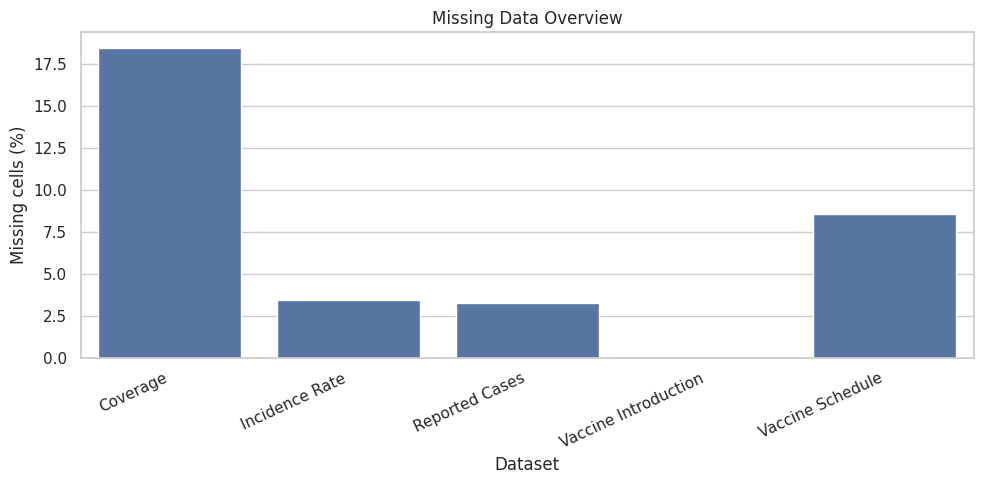

In [8]:
rows = []
for name, df in datasets.items():
    total = df.size
    missing = int(df.isna().sum().sum())
    rows.append({
        "Dataset": name,
        "Missing Cells": missing,
        "Missing %": round(missing / total * 100, 2) if total else 0
    })

missing_overview = pd.DataFrame(rows)
display(missing_overview)

plt.figure(figsize=(10, 5))
sns.barplot(data=missing_overview, x="Dataset", y="Missing %")
plt.xticks(rotation=25, ha="right")
plt.ylabel("Missing cells (%)")
plt.title("Missing Data Overview")
plt.tight_layout()
plt.show()


# What did you know about the datasets?

The five WHO datasets cover complementary parts of the vaccination domain: vaccination coverage, disease incidence, reported disease cases, vaccine introduction and vaccination schedules. Together they support country-level and year-level analysis of coverage, disease burden, dose completion and vaccine rollout. The datasets do not contain every demographic or intervention variable mentioned in the original brief, so unsupported questions are not fabricated in this notebook.


# 2. Understanding Your Variables


# Dataset Columns


In [9]:
for name, df in datasets.items():
    print(f"\n{name} columns:")
    print(list(df.columns))



Coverage columns:
['GROUP', 'CODE', 'NAME', 'YEAR', 'ANTIGEN', 'ANTIGEN_DESCRIPTION', 'COVERAGE_CATEGORY', 'COVERAGE_CATEGORY_DESCRIPTION', 'TARGET_NUMBER', 'DOSES', 'COVERAGE']

Incidence Rate columns:
['GROUP', 'CODE', 'NAME', 'YEAR', 'DISEASE', 'DISEASE_DESCRIPTION', 'DENOMINATOR', 'INCIDENCE_RATE']

Reported Cases columns:
['GROUP', 'CODE', 'NAME', 'YEAR', 'DISEASE', 'DISEASE_DESCRIPTION', 'CASES']

Vaccine Introduction columns:
['ISO_3_CODE', 'COUNTRYNAME', 'WHO_REGION', 'YEAR', 'DESCRIPTION', 'INTRO']

Vaccine Schedule columns:
['ISO_3_CODE', 'COUNTRYNAME', 'WHO_REGION', 'YEAR', 'VACCINECODE', 'VACCINE_DESCRIPTION', 'SCHEDULEROUNDS', 'TARGETPOP', 'TARGETPOP_DESCRIPTION', 'GEOAREA', 'AGEADMINISTERED', 'SOURCECOMMENT']


# Dataset Describe


In [10]:
for name, df in datasets.items():
    print(f"\n{name} numerical and descriptive summary")
    display(df.describe(include="all").transpose().head(30))



Coverage numerical and descriptive summary


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
GROUP,399859,9,COUNTRIES,381041,NaN,NaN,NaN,NaN,NaN,NaN,NaN
CODE,399858,245,ETH,2031,NaN,NaN,NaN,NaN,NaN,NaN,NaN
NAME,398584,242,Ethiopia,2031,NaN,NaN,NaN,NaN,NaN,NaN,NaN
YEAR,399858.0,NaN,NaN,NaN,2009.207489,11.72053,1980.0,2002.0,2012.0,2019.0,2023.0
ANTIGEN,399858,69,DTPCV3,26015,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ANTIGEN_DESCRIPTION,399858,69,"DTP-containing vaccine, 3rd dose",26015,NaN,NaN,NaN,NaN,NaN,NaN,NaN
COVERAGE_CATEGORY,399858,5,ADMIN,155576,NaN,NaN,NaN,NaN,NaN,NaN,NaN
COVERAGE_CATEGORY_DESCRIPTION,399858,5,Administrative coverage,155576,NaN,NaN,NaN,NaN,NaN,NaN,NaN
TARGET_NUMBER,79030.0,NaN,NaN,NaN,278019173.759516,54152442883.354065,0.0,32814.0,317871.5,2493048.0,11700000000000.0
DOSES,79327.0,NaN,NaN,NaN,3467241.121352,11256763.030974,-222288203.0,14469.0,152212.0,971018.5,126605212.0



Incidence Rate numerical and descriptive summary


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
GROUP,84946,4,COUNTRIES,82054,NaN,NaN,NaN,NaN,NaN,NaN,NaN
CODE,84945,221,GLOBAL,424,NaN,NaN,NaN,NaN,NaN,NaN,NaN
NAME,84945,221,Global,424,NaN,NaN,NaN,NaN,NaN,NaN,NaN
YEAR,84945.0,NaN,NaN,NaN,2004.095791,12.595166,1980.0,1994.0,2005.0,2015.0,2023.0
DISEASE,84945,13,MEASLES,9196,NaN,NaN,NaN,NaN,NaN,NaN,NaN
DISEASE_DESCRIPTION,84945,13,Measles,9196,NaN,NaN,NaN,NaN,NaN,NaN,NaN
DENOMINATOR,84945,5,"per 1,000,000 total population",61480,NaN,NaN,NaN,NaN,NaN,NaN,NaN
INCIDENCE_RATE,61584.0,NaN,NaN,NaN,109.448781,992.276983,0.0,0.0,0.0,4.6,69101.3



Reported Cases numerical and descriptive summary


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
GROUP,84870,4,COUNTRIES,82054,NaN,NaN,NaN,NaN,NaN,NaN,NaN
CODE,84869,221,GLOBAL,424,NaN,NaN,NaN,NaN,NaN,NaN,NaN
NAME,84869,221,Global,424,NaN,NaN,NaN,NaN,NaN,NaN,NaN
YEAR,84869.0,NaN,NaN,NaN,2004.108261,12.591396,1980.0,1994.0,2005.0,2015.0,2023.0
DISEASE,84869,13,MEASLES,9196,NaN,NaN,NaN,NaN,NaN,NaN,NaN
DISEASE_DESCRIPTION,84869,13,Measles,9196,NaN,NaN,NaN,NaN,NaN,NaN,NaN
CASES,65470.0,NaN,NaN,NaN,4472.408569,61144.550256,0.0,0.0,1.0,63.0,4583555.0



Vaccine Introduction numerical and descriptive summary


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
ISO_3_CODE,138321,195,AFG,747,NaN,NaN,NaN,NaN,NaN,NaN,NaN
COUNTRYNAME,138320,194,Afghanistan,747,NaN,NaN,NaN,NaN,NaN,NaN,NaN
WHO_REGION,138320,6,EURO,34523,NaN,NaN,NaN,NaN,NaN,NaN,NaN
YEAR,138320.0,NaN,NaN,NaN,2001.267879,17.679511,1940.0,1992.0,2006.0,2015.0,2023.0
DESCRIPTION,138320,21,Seasonal Influenza vaccine,14715,NaN,NaN,NaN,NaN,NaN,NaN,NaN
INTRO,138320,9,No,97695,NaN,NaN,NaN,NaN,NaN,NaN,NaN



Vaccine Schedule numerical and descriptive summary


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
ISO_3_CODE,8053,214,RUS,126,NaN,NaN,NaN,NaN,NaN,NaN,NaN
COUNTRYNAME,8052,213,Russian Federation,126,NaN,NaN,NaN,NaN,NaN,NaN,NaN
WHO_REGION,8052,6,EURO,2156,NaN,NaN,NaN,NaN,NaN,NaN,NaN
YEAR,8052.0,NaN,NaN,NaN,2022.941505,0.441237,2019.0,2023.0,2023.0,2023.0,2023.0
VACCINECODE,8052,86,TD_S,967,NaN,NaN,NaN,NaN,NaN,NaN,NaN
VACCINE_DESCRIPTION,8052,86,Td (Tetanus toxoid and diphtheria for older ch...,967,NaN,NaN,NaN,NaN,NaN,NaN,NaN
SCHEDULEROUNDS,8052.0,NaN,NaN,NaN,2.053403,1.31656,1.0,1.0,2.0,3.0,7.0
TARGETPOP,3795,15,RISKGROUPS,1247,NaN,NaN,NaN,NaN,NaN,NaN,NaN
TARGETPOP_DESCRIPTION,8052,10,General/routine,4695,NaN,NaN,NaN,NaN,NaN,NaN,NaN
GEOAREA,8022,2,NATIONAL,7788,NaN,NaN,NaN,NaN,NaN,NaN,NaN


# Variables Description

**Coverage:** country/group, ISO code, year, antigen/vaccine, coverage category, target population, dose information and coverage percentage where supplied.

**Incidence Rate:** country/group, ISO code, year, disease, denominator and incidence rate.

**Reported Cases:** country/group, ISO code, year, disease and reported cases.

**Vaccine Introduction:** country, WHO region, year, vaccine description and introduction status.

**Vaccine Schedule:** country, WHO region, year, vaccine code/description, schedule rounds, target population, age and geographic information.

The notebook prints the exact columns from the uploaded files so every calculation can be checked against the source data.


# Check Unique Values for Each Variable


In [11]:
for name, df in datasets.items():
    print(f"\n{name}")
    summary = pd.DataFrame({
        "Column": df.columns,
        "Unique Values": [df[c].nunique(dropna=True) for c in df.columns]
    })
    display(summary)



Coverage


,Column,Unique Values
0,GROUP,9
1,CODE,245
2,NAME,242
3,YEAR,44
4,ANTIGEN,69
5,ANTIGEN_DESCRIPTION,69
6,COVERAGE_CATEGORY,5
7,COVERAGE_CATEGORY_DESCRIPTION,5
8,TARGET_NUMBER,24395
9,DOSES,53792



Incidence Rate


,Column,Unique Values
0,GROUP,4
1,CODE,221
2,NAME,221
3,YEAR,44
4,DISEASE,13
5,DISEASE_DESCRIPTION,13
6,DENOMINATOR,5
7,INCIDENCE_RATE,4977



Reported Cases


,Column,Unique Values
0,GROUP,4
1,CODE,221
2,NAME,221
3,YEAR,44
4,DISEASE,13
5,DISEASE_DESCRIPTION,13
6,CASES,6634



Vaccine Introduction


,Column,Unique Values
0,ISO_3_CODE,195
1,COUNTRYNAME,194
2,WHO_REGION,6
3,YEAR,84
4,DESCRIPTION,21
5,INTRO,9



Vaccine Schedule


,Column,Unique Values
0,ISO_3_CODE,214
1,COUNTRYNAME,213
2,WHO_REGION,6
3,YEAR,4
4,VACCINECODE,86
5,VACCINE_DESCRIPTION,86
6,SCHEDULEROUNDS,7
7,TARGETPOP,15
8,TARGETPOP_DESCRIPTION,10
9,GEOAREA,2


# 3. Data Wrangling


# Data Wrangling Code


In [12]:
def clean_columns(df):
    df = df.copy()
    df.columns = [
        re.sub(r"[^a-z0-9]+", "_", str(c).strip().lower()).strip("_")
        for c in df.columns
    ]
    return df

coverage = clean_columns(coverage_df)
incidence = clean_columns(incidence_df)
cases = clean_columns(cases_df)
introduction = clean_columns(intro_df)
schedule = clean_columns(schedule_df)

# Convert year fields to numeric where available.
for df in [coverage, incidence, cases, introduction, schedule]:
    if "year" in df.columns:
        df["year"] = pd.to_numeric(df["year"], errors="coerce")

# Convert common analytical measures to numeric where available.
numeric_candidates = {
    "coverage": ["coverage", "target_number", "target_pop", "doses"],
    "incidence": ["incidence_rate", "denominator"],
    "cases": ["cases", "reported_cases"],
}

for df_name, cols in numeric_candidates.items():
    df = {"coverage": coverage, "incidence": incidence, "cases": cases}[df_name]
    for col in cols:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors="coerce")

# Standardize text values without changing their meaning.
for df in [coverage, incidence, cases, introduction, schedule]:
    for col in df.select_dtypes(include="object").columns:
        df[col] = df[col].astype("string").str.strip()

# Remove only exact duplicate rows.
coverage = coverage.drop_duplicates().reset_index(drop=True)
incidence = incidence.drop_duplicates().reset_index(drop=True)
cases = cases.drop_duplicates().reset_index(drop=True)
introduction = introduction.drop_duplicates().reset_index(drop=True)
schedule = schedule.drop_duplicates().reset_index(drop=True)

cleaned_datasets = {
    "Coverage": coverage,
    "Incidence Rate": incidence,
    "Reported Cases": cases,
    "Vaccine Introduction": introduction,
    "Vaccine Schedule": schedule,
}

print("Cleaning completed.")
for name, df in cleaned_datasets.items():
    print(f"{name:22s}: {len(df):,} rows")


Cleaning completed.
Coverage              : 399,859 rows
Incidence Rate        : 84,946 rows
Reported Cases        : 84,870 rows
Vaccine Introduction  : 138,321 rows
Vaccine Schedule      : 8,053 rows


# Data Wrangling: What was done?

The notebook standardizes column names, converts year and analytical measures to numeric types where applicable, trims text fields, removes only exact duplicate rows and keeps missing values visible rather than replacing them with arbitrary numbers. These steps make the five WHO datasets easier to analyze while preserving the meaning of the source data.


In [13]:
def find_col(df, candidates):
    normalized = {
        str(c).lower().replace(" ", "_"): c
        for c in df.columns
    }
    for cand in candidates:
        key = cand.lower().replace(" ", "_")
        if key in normalized:
            return normalized[key]
    for c in df.columns:
        lc = str(c).lower().replace(" ", "_")
        if any(cand.lower().replace(" ", "_") in lc for cand in candidates):
            return c
    return None

# Detect project fields from the actual uploaded schema.
year_col = find_col(coverage, ["year"])
country_col = find_col(coverage, ["name", "country_name"])
code_col = find_col(coverage, ["code", "iso_3_code"])
antigen_col = find_col(coverage, ["antigen", "vaccine_code"])
coverage_col = find_col(coverage, ["coverage"])

inc_year = find_col(incidence, ["year"])
inc_country = find_col(incidence, ["name", "country_name"])
inc_disease = find_col(incidence, ["disease_description", "disease"])
inc_rate = find_col(incidence, ["incidence_rate"])

cases_year = find_col(cases, ["year"])
cases_country = find_col(cases, ["name", "country_name"])
cases_disease = find_col(cases, ["disease_description", "disease"])
cases_value = find_col(cases, ["cases", "reported_cases"])

intro_year = find_col(introduction, ["year"])
intro_country = find_col(introduction, ["country_name", "name"])
intro_region = find_col(introduction, ["who_region", "region"])
intro_vaccine = find_col(introduction, ["description", "vaccine_description"])
intro_status = find_col(introduction, ["intro", "introduction", "status"])

sched_year = find_col(schedule, ["year"])
sched_vaccine = find_col(schedule, ["vaccine_code", "vaccine_description"])
sched_round = find_col(schedule, ["schedule_rounds", "schedule_round"])

detected = {
    "coverage country": country_col,
    "coverage year": year_col,
    "antigen": antigen_col,
    "coverage": coverage_col,
    "incidence country": inc_country,
    "incidence year": inc_year,
    "incidence disease": inc_disease,
    "incidence rate": inc_rate,
    "cases country": cases_country,
    "cases year": cases_year,
    "cases disease": cases_disease,
    "reported cases": cases_value,
    "introduction region": intro_region,
    "introduction year": intro_year,
    "introduction status": intro_status,
    "schedule round": sched_round,
}
display(pd.DataFrame({"Analytical Field": detected.keys(), "Detected Column": detected.values()}))


,Analytical Field,Detected Column
0,coverage country,name
1,coverage year,year
2,antigen,antigen
3,coverage,coverage
4,incidence country,name
5,incidence year,year
6,incidence disease,disease_description
7,incidence rate,incidence_rate
8,cases country,name
9,cases year,year


# 4. Exploratory Data Analysis


# Chart - 1: Global DTP3 Coverage Trend


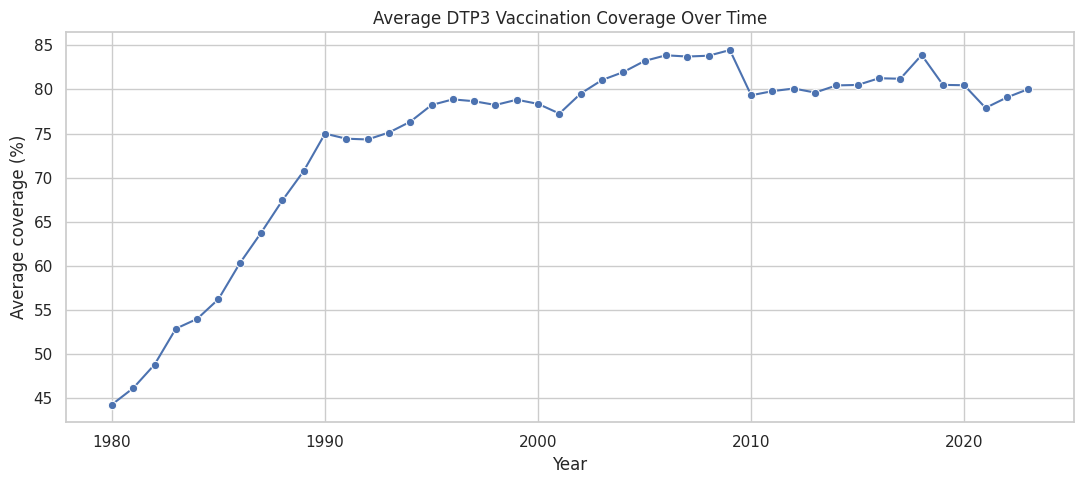

,year,coverage
34,2014.0,80.461696
35,2015.0,80.513076
36,2016.0,81.274453
37,2017.0,81.216230
38,2018.0,83.907838
39,2019.0,80.521072
40,2020.0,80.479767
41,2021.0,77.907310
42,2022.0,79.094810
43,2023.0,80.039306


In [14]:
plot_df = coverage.copy()

if antigen_col and coverage_col and year_col:
    mask = plot_df[antigen_col].astype("string").str.upper().str.contains("DTP3", na=False)
    if mask.any():
        plot_df = plot_df.loc[mask]

    trend = (
        plot_df.groupby(year_col, as_index=False)[coverage_col]
        .mean()
        .dropna()
        .sort_values(year_col)
    )

    plt.figure(figsize=(11, 5))
    sns.lineplot(data=trend, x=year_col, y=coverage_col, marker="o")
    plt.title("Average DTP3 Vaccination Coverage Over Time")
    plt.xlabel("Year")
    plt.ylabel("Average coverage (%)")
    plt.tight_layout()
    plt.show()
    display(trend.tail(10))
else:
    print("Required coverage/year columns are not available in the uploaded coverage file.")


# Why did you pick this chart?

A line chart is appropriate because the project contains annual vaccination coverage data and the question is about change over time.


# What is or are the insights found from the chart?

The output shows how the average recorded DTP3 coverage changes across the available years. The exact pattern is calculated from the uploaded WHO data when the notebook is run.


# Will the gained insights help create a positive business impact?

The trend helps monitor whether vaccination coverage is improving, stable or declining and can support further public-health investigation.


# Chart - 2: Highest and Lowest DTP3 Coverage Countries


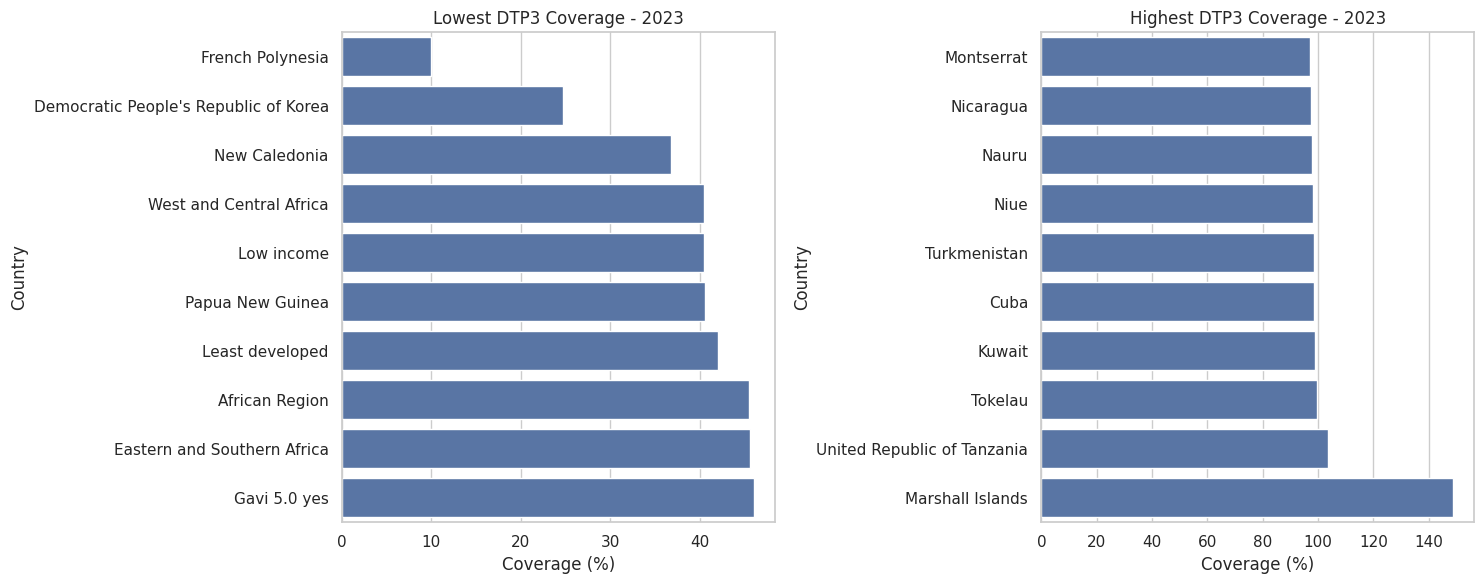

In [15]:
if antigen_col and year_col and coverage_col and country_col:
    plot_df = coverage.copy()
    mask = plot_df[antigen_col].astype("string").str.upper().str.contains("DTP3", na=False)
    if mask.any():
        plot_df = plot_df.loc[mask]

    latest = int(plot_df[year_col].dropna().max()) if plot_df[year_col].notna().any() else None
    if latest is not None:
        plot_df = plot_df[plot_df[year_col] == latest]

    country_avg = (
        plot_df.groupby(country_col, as_index=False)[coverage_col]
        .mean()
        .dropna()
        .sort_values(coverage_col)
    )

    bottom = country_avg.head(10)
    top = country_avg.tail(10).sort_values(coverage_col)

    fig, axes = plt.subplots(1, 2, figsize=(15, 6))
    sns.barplot(data=bottom, x=coverage_col, y=country_col, ax=axes[0])
    axes[0].set_title(f"Lowest DTP3 Coverage - {latest}")
    axes[0].set_xlabel("Coverage (%)")
    axes[0].set_ylabel("Country")

    sns.barplot(data=top, x=coverage_col, y=country_col, ax=axes[1])
    axes[1].set_title(f"Highest DTP3 Coverage - {latest}")
    axes[1].set_xlabel("Coverage (%)")
    axes[1].set_ylabel("Country")

    plt.tight_layout()
    plt.show()
else:
    print("Required DTP3 coverage columns are not available.")


# Why did you pick this chart?

Horizontal bar charts make country names readable and make the highest and lowest coverage groups easy to compare.


# What is or are the insights found from the chart?

The chart identifies the countries at the two ends of the recorded DTP3 coverage distribution for the latest available year in the uploaded data.


# Will the gained insights help create a positive business impact?

This is directly useful for identifying coverage gaps and locations that may need further public-health investigation.


# Chart - 3: First Dose vs Third Dose Coverage


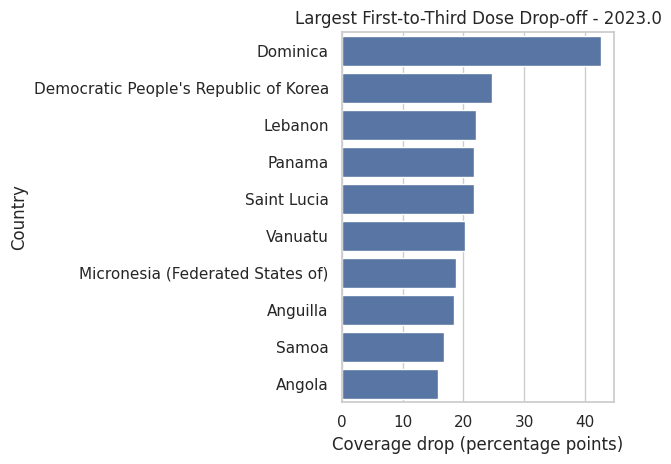

,name,year,dose1,dose3,drop_off
2403,Dominica,2023.0,98.853333,56.153333,42.700000
2098,Democratic People's Republic of Korea,2023.0,41.000000,16.193333,24.806667
4871,Lebanon,2023.0,82.580000,60.473333,22.106667
6572,Panama,2023.0,88.060000,66.293333,21.766667
7201,Saint Lucia,2023.0,95.753333,74.053333,21.700000
9026,Vanuatu,2023.0,89.333333,69.000000,20.333333
5602,Micronesia (Federated States of),2023.0,97.733333,79.006667,18.726667
249,Anguilla,2023.0,108.550000,90.060000,18.490000
7289,Samoa,2023.0,99.835000,83.075000,16.760000
241,Angola,2023.0,84.060000,68.240000,15.820000


In [16]:
if antigen_col and year_col and coverage_col and country_col:
    tmp = coverage.copy()
    tmp["antigen_upper"] = tmp[antigen_col].astype("string").str.upper()

    first = tmp[tmp["antigen_upper"].str.contains("DTPCV1|DTP1", regex=True, na=False)]
    third = tmp[tmp["antigen_upper"].str.contains("DTPCV3|DTP3", regex=True, na=False)]

    if not first.empty and not third.empty:
        a = first.groupby([country_col, year_col])[coverage_col].mean().rename("dose1")
        b = third.groupby([country_col, year_col])[coverage_col].mean().rename("dose3")

        drop = pd.concat([a, b], axis=1).dropna().reset_index()
        drop["drop_off"] = drop["dose1"] - drop["dose3"]

        latest = drop[year_col].max()
        d = (
            drop[drop[year_col] == latest]
            .sort_values("drop_off", ascending=False)
            .head(10)
        )

        sns.barplot(data=d, x="drop_off", y=country_col)
        plt.title(f"Largest First-to-Third Dose Drop-off - {latest}")
        plt.xlabel("Coverage drop (percentage points)")
        plt.ylabel("Country")
        plt.tight_layout()
        plt.show()
        display(d)
    else:
        print("DTPCV1/DTPCV3 records were not detected in the uploaded coverage data.")
else:
    print("Required coverage columns are not available.")


# Why did you pick this chart?

The first-dose versus third-dose comparison directly matches the project's dose drop-off requirement and shows where completion falls after initial uptake.


# What is or are the insights found from the chart?

The table and chart calculate the difference between first-dose and third-dose coverage for countries where both records are available.


# Will the gained insights help create a positive business impact?

The result can help identify countries where maintaining vaccination through later doses may need further attention.


# Chart - 4: Disease Reported Cases Trend


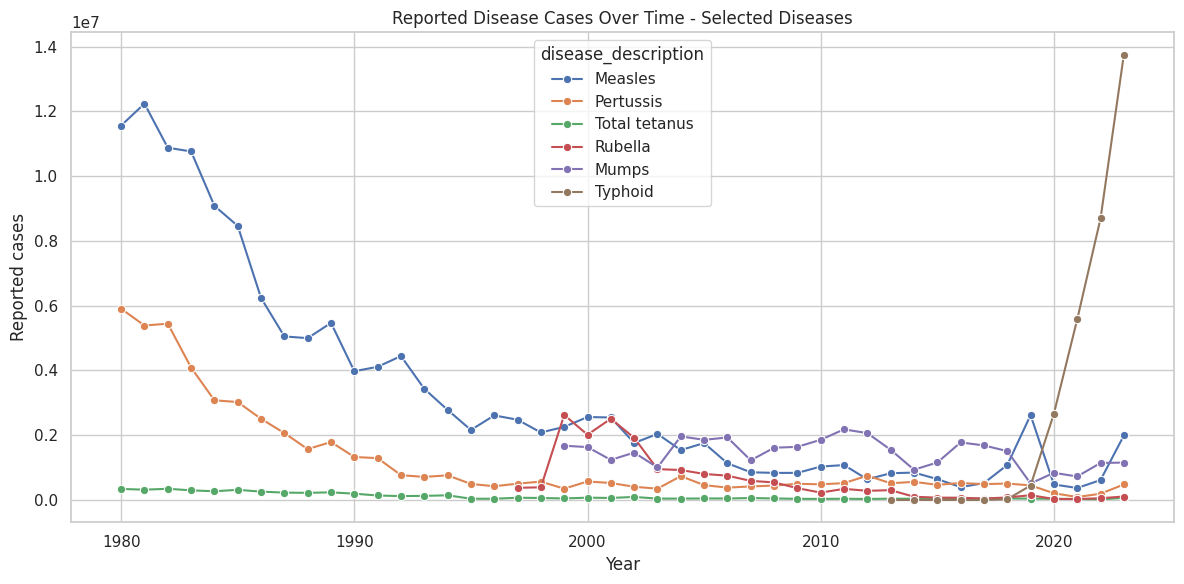

In [17]:
if cases_year and cases_disease and cases_value:
    top_diseases = cases.groupby(cases_disease)[cases_value].sum().nlargest(6).index
    t = (
        cases[cases[cases_disease].isin(top_diseases)]
        .groupby([cases_year, cases_disease], as_index=False)[cases_value]
        .sum()
    )

    plt.figure(figsize=(12, 6))
    sns.lineplot(data=t, x=cases_year, y=cases_value, hue=cases_disease, marker="o")
    plt.title("Reported Disease Cases Over Time - Selected Diseases")
    plt.xlabel("Year")
    plt.ylabel("Reported cases")
    plt.tight_layout()
    plt.show()
else:
    print("Required disease-case columns are not available.")


# Why did you pick this chart?

A multi-line chart is suitable for comparing how reported disease cases change across years for several diseases.


# What is or are the insights found from the chart?

The chart shows the actual reported-case trends calculated from the WHO reported-cases dataset; no disease trend is inserted manually.


# Will the gained insights help create a positive business impact?

It helps identify diseases or periods with increasing or decreasing reported burden and supports further investigation alongside vaccination coverage.


# Chart - 5: Vaccine Introduction Trend


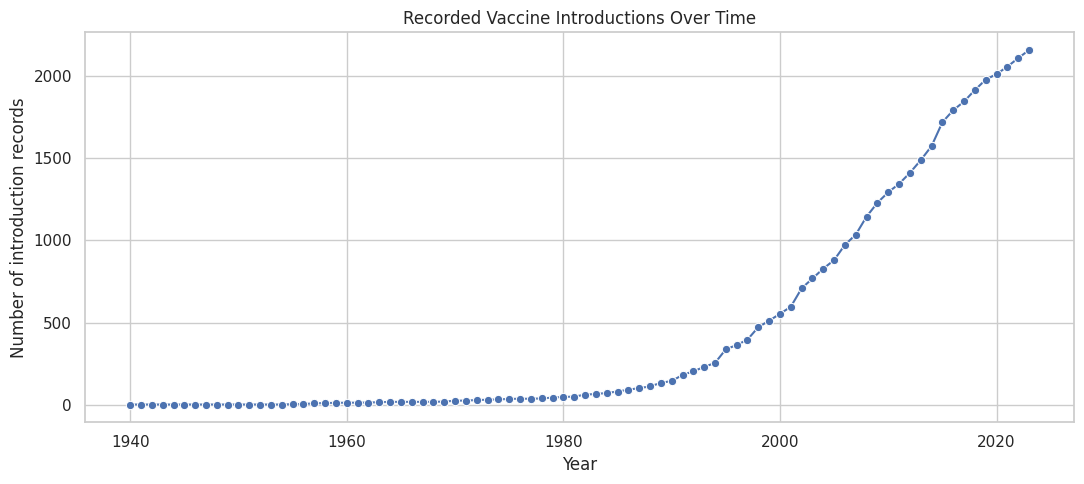

,year,Introduction records
0,1940.0,1
1,1941.0,1
2,1942.0,1
3,1943.0,1
4,1944.0,1
5,1945.0,1
6,1946.0,1
7,1947.0,1
8,1948.0,1
9,1949.0,1


In [18]:
if intro_year and intro_status:
    x = introduction.copy()
    status = x[intro_status].astype("string").str.upper().str.strip()

    # Detect common positive introduction/status values from the actual file.
    positive_values = {"1", "YES", "Y", "TRUE", "INTRODUCED"}
    introduced = status.isin(positive_values)

    if introduced.any():
        trend = (
            x.loc[introduced]
            .groupby(intro_year)
            .size()
            .reset_index(name="Introduction records")
            .sort_values(intro_year)
        )

        plt.figure(figsize=(11, 5))
        sns.lineplot(data=trend, x=intro_year, y="Introduction records", marker="o")
        plt.title("Recorded Vaccine Introductions Over Time")
        plt.xlabel("Year")
        plt.ylabel("Number of introduction records")
        plt.tight_layout()
        plt.show()
        display(trend)
    else:
        print("No standard positive introduction values were detected.")
        print("Observed status values:")
        display(x[intro_status].dropna().astype("string").str.strip().value_counts().head(20))
else:
    print("Required vaccine-introduction columns are not available.")


# Why did you pick this chart?

A time-series chart fits the vaccine-introduction data because the project examines rollout timelines by year.


# What is or are the insights found from the chart?

The output counts positive introduction records by year based on the actual status values in the uploaded dataset.


# Will the gained insights help create a positive business impact?

This provides a clear view of how recorded vaccine rollout activity changes over time and supports comparison of introduction timelines.


# Chart - 6: Vaccine Introduction by WHO Region


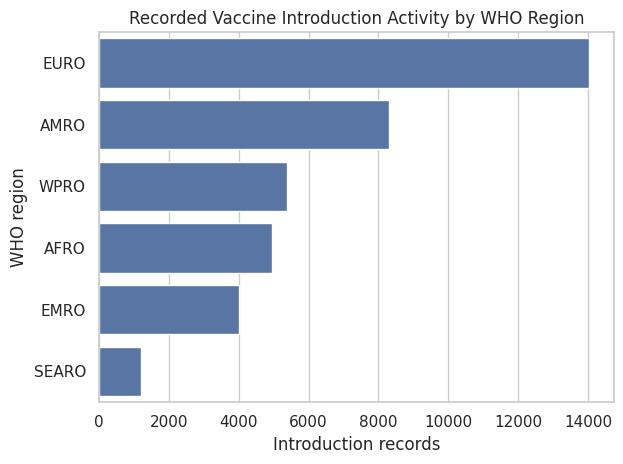

,who_region,Introduction records
3,EURO,14045
1,AMRO,8289
5,WPRO,5367
0,AFRO,4948
2,EMRO,4002
4,SEARO,1193


In [19]:
if intro_region and intro_year and intro_status:
    x = introduction.copy()
    status = x[intro_status].astype("string").str.upper().str.strip()
    positive_values = {"1", "YES", "Y", "TRUE", "INTRODUCED"}
    introduced = status.isin(positive_values)

    if introduced.any():
        reg = (
            x.loc[introduced]
            .groupby(intro_region)
            .size()
            .reset_index(name="Introduction records")
            .sort_values("Introduction records", ascending=False)
        )

        sns.barplot(data=reg, x="Introduction records", y=intro_region)
        plt.title("Recorded Vaccine Introduction Activity by WHO Region")
        plt.xlabel("Introduction records")
        plt.ylabel("WHO region")
        plt.tight_layout()
        plt.show()
        display(reg)
    else:
        print("No standard positive introduction values were detected.")
else:
    print("Required WHO region/introduction columns are not available.")


# Why did you pick this chart?

A regional bar chart is appropriate because the project examines whether recorded vaccine introduction timelines differ across WHO regions.


# What is or are the insights found from the chart?

The chart compares recorded positive introduction entries by WHO region. It describes rollout records, not physical stock availability.


# Will the gained insights help create a positive business impact?

Regional differences can help users understand where vaccine introduction occurred earlier or later and where further rollout investigation may be useful.


# Chart - 7: DTP3 Coverage vs Pertussis Incidence


In [20]:
if (country_col and year_col and coverage_col and antigen_col and
    inc_country and inc_year and inc_rate and inc_disease):

    c = coverage.copy()
    c["antigen_upper"] = c[antigen_col].astype("string").str.upper()
    c = c[c["antigen_upper"].str.contains("DTP3", na=False)]

    if not c.empty and c[year_col].notna().any():
        cov_year = int(c[year_col].max())
        c = c[c[year_col] == cov_year]
        c = c.groupby(country_col, as_index=False)[coverage_col].mean()
    else:
        c = pd.DataFrame()

    i = incidence.copy()
    i = i[i[inc_disease].astype("string").str.upper().str.contains("PERTUSSIS", na=False)]

    if not i.empty and i[inc_year].notna().any():
        inc_year_latest = int(i[inc_year].max())
        i = i[i[inc_year] == inc_year_latest]
        i = i.groupby(inc_country, as_index=False)[inc_rate].mean()
    else:
        i = pd.DataFrame()

    if not c.empty and not i.empty:
        merged = (
            c.merge(i, left_on=country_col, right_on=inc_country, how="inner")
            .dropna(subset=[coverage_col, inc_rate])
        )

        if len(merged) >= 3:
            corr = merged[coverage_col].corr(merged[inc_rate])

            sns.regplot(
                data=merged,
                x=coverage_col,
                y=inc_rate,
                scatter_kws={"alpha": 0.6}
            )
            plt.title(f"DTP3 Coverage vs Pertussis Incidence (r = {corr:.3f})")
            plt.xlabel(f"DTP3 coverage (%) - {cov_year}")
            plt.ylabel(f"Pertussis incidence rate - {inc_year_latest}")
            plt.tight_layout()
            plt.show()

            print(f"Pearson correlation: {corr:.3f}")
            display(merged.sort_values(inc_rate, ascending=False).head(10))
        else:
            print("Not enough matched country records for correlation.")
    else:
        print("DTP3 coverage or Pertussis incidence records were not available for a matched analysis.")
else:
    print("Required columns for DTP3 versus Pertussis analysis are not available.")


DTP3 coverage or Pertussis incidence records were not available for a matched analysis.


# Why did you pick this chart?

A scatter plot is appropriate for examining the relationship between two continuous measures: vaccination coverage and disease incidence.


# What is or are the insights found from the chart?

The cell calculates the Pearson correlation from matched country records and displays a trend line. The exact correlation is generated from the uploaded WHO data when the notebook runs.


# Will the gained insights help create a positive business impact?

This is the project's main vaccination-versus-disease analysis. It can identify patterns and outliers for further investigation, but correlation alone does not establish causation.


# Chart - 8: Disease Burden by Country


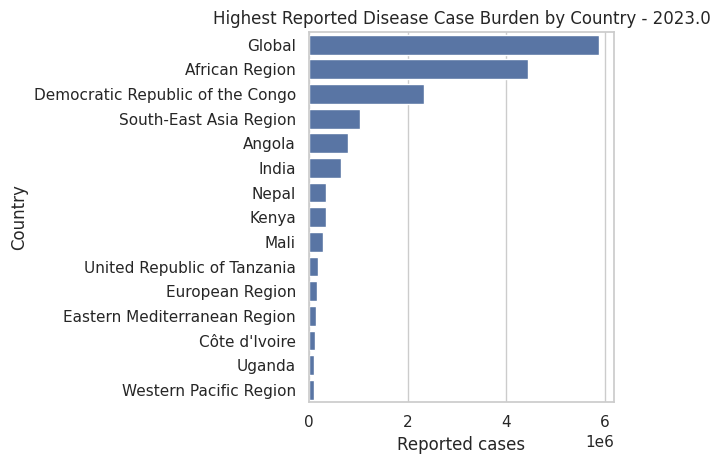

,name,cases
79,Global,5889122.0
1,African Region,4449384.0
55,Democratic Republic of the Congo,2338752.0
181,South-East Asia Region,1034459.0
5,Angola,793825.0
91,India,652732.0
135,Nepal,354200.0
102,Kenya,335173.0
119,Mali,278930.0
205,United Republic of Tanzania,180579.0


In [21]:
if cases_country and cases_value and cases_year and cases_disease:
    latest = cases[cases_year].max()
    x = (
        cases[cases[cases_year] == latest]
        .groupby(cases_country, as_index=False)[cases_value]
        .sum()
        .nlargest(15, cases_value)
    )

    sns.barplot(data=x, x=cases_value, y=cases_country)
    plt.title(f"Highest Reported Disease Case Burden by Country - {latest}")
    plt.xlabel("Reported cases")
    plt.ylabel("Country")
    plt.tight_layout()
    plt.show()
    display(x)
else:
    print("Required reported-case columns are not available.")


# Why did you pick this chart?

A country-level bar chart makes geographic differences in reported disease burden easy to compare.


# What is or are the insights found from the chart?

The chart ranks countries by total reported cases in the latest available year in the uploaded dataset. The ranking is calculated from the data at runtime.


# Will the gained insights help create a positive business impact?

It can help identify locations with higher recorded disease burden that may warrant closer analysis of coverage and other factors.


# Chart - 9: Coverage Distribution


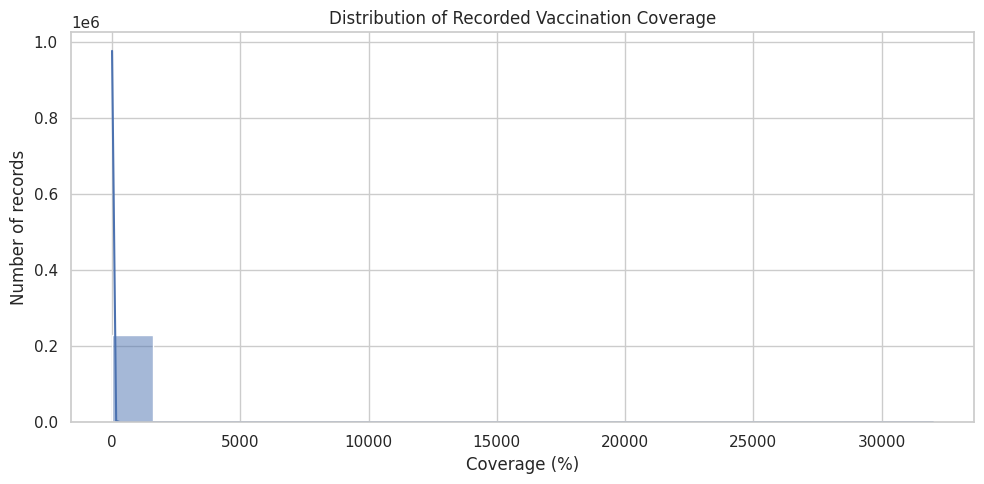

,Coverage
count,230477.000000
mean,78.032914
std,74.891697
min,0.000000
25%,69.320000
50%,88.790000
75%,96.000000
max,32000.000000


In [22]:
if coverage_col:
    x = coverage[coverage_col].dropna()

    plt.figure(figsize=(10, 5))
    sns.histplot(x, bins=20, kde=True)
    plt.title("Distribution of Recorded Vaccination Coverage")
    plt.xlabel("Coverage (%)")
    plt.ylabel("Number of records")
    plt.tight_layout()
    plt.show()

    display(x.describe().to_frame("Coverage"))
else:
    print("Coverage column is not available.")


# Why did you pick this chart?

A histogram shows the overall distribution of recorded coverage values and helps identify concentration, spread and unusually low or high values.


# What is or are the insights found from the chart?

The summary statistics and histogram describe how vaccination coverage values are distributed in the supplied coverage dataset.


# Will the gained insights help create a positive business impact?

Understanding the distribution helps distinguish broadly high-coverage records from lower-coverage records and supports coverage-gap analysis.


# Chart - 10: Vaccine Coverage by Antigen


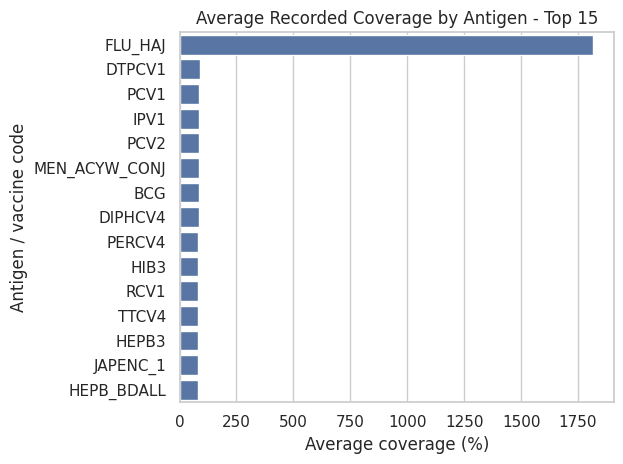

,antigen,coverage
17,FLU_HAJ,1817.277222
8,DTPCV1,89.734332
48,PCV1,87.771971
28,IPV1,85.040347
49,PCV2,84.983896
44,MEN_ACYW_CONJ,84.433636
4,BCG,84.145933
5,DIPHCV4,83.675817
51,PERCV4,83.378889
25,HIB3,82.974179


In [23]:
if antigen_col and coverage_col:
    x = (
        coverage.groupby(antigen_col, as_index=False)[coverage_col]
        .mean()
        .dropna()
        .sort_values(coverage_col, ascending=False)
        .head(15)
    )

    sns.barplot(data=x, x=coverage_col, y=antigen_col)
    plt.title("Average Recorded Coverage by Antigen - Top 15")
    plt.xlabel("Average coverage (%)")
    plt.ylabel("Antigen / vaccine code")
    plt.tight_layout()
    plt.show()
    display(x)
else:
    print("Required antigen/coverage columns are not available.")


# Why did you pick this chart?

A horizontal bar chart is useful for comparing average recorded coverage across vaccine antigens.


# What is or are the insights found from the chart?

The chart compares the top recorded antigen coverage averages in the supplied data. It is a coverage comparison, not a ranking of vaccine effectiveness.


# Will the gained insights help create a positive business impact?

This comparison helps identify which vaccine records show higher or lower coverage and where coverage gaps may deserve attention.


# Chart - 11: Disease Incidence by Disease


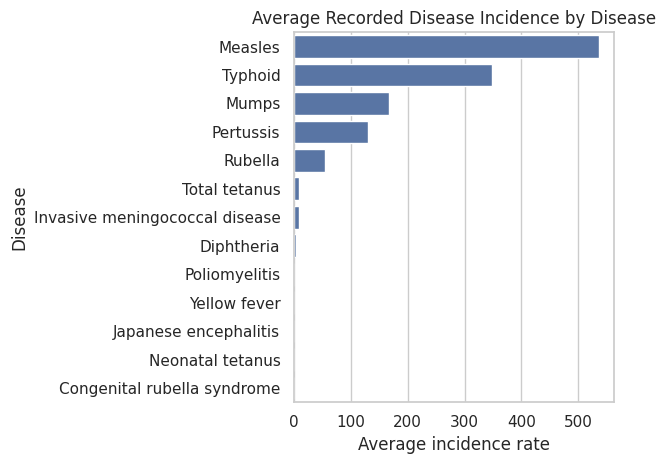

,disease_description,incidence_rate
4,Measles,535.640943
11,Typhoid,348.502894
5,Mumps,168.046005
7,Pertussis,130.545548
9,Rubella,54.347889
10,Total tetanus,9.888190
2,Invasive meningococcal disease,8.859831
1,Diphtheria,4.259208
8,Poliomyelitis,0.874932
12,Yellow fever,0.556010


In [24]:
if inc_disease and inc_rate:
    x = (
        incidence.groupby(inc_disease, as_index=False)[inc_rate]
        .mean()
        .dropna()
        .sort_values(inc_rate, ascending=False)
        .head(15)
    )

    sns.barplot(data=x, x=inc_rate, y=inc_disease)
    plt.title("Average Recorded Disease Incidence by Disease")
    plt.xlabel("Average incidence rate")
    plt.ylabel("Disease")
    plt.tight_layout()
    plt.show()
    display(x)
else:
    print("Required incidence columns are not available.")


# Why did you pick this chart?

A bar chart is suitable for comparing the average recorded incidence rate across diseases.


# What is or are the insights found from the chart?

The chart shows diseases with higher average recorded incidence rates in the supplied incidence dataset. The source definitions and denominators should be considered when comparing diseases.


# Will the gained insights help create a positive business impact?

It provides a high-level view of recorded disease burden and helps select diseases for deeper country- and time-based analysis.


# Chart - 12: Correlation Matrix of Available Numeric Measures


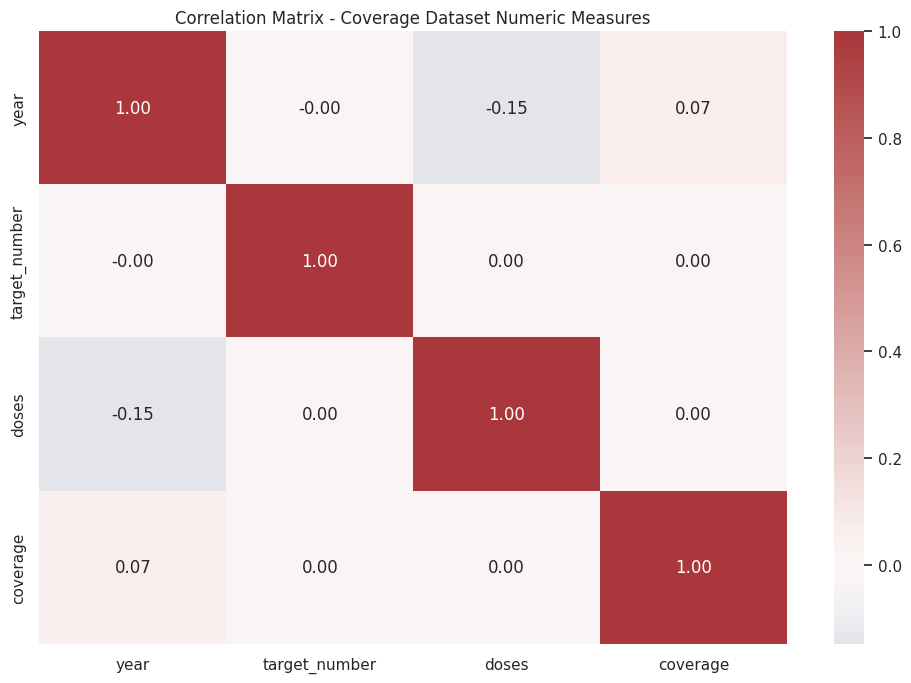

In [25]:
num = coverage.select_dtypes(include=np.number).copy()

if num.shape[1] >= 2:
    corr = num.corr(numeric_only=True)

    plt.figure(figsize=(10, 7))
    sns.heatmap(corr, annot=True, fmt=".2f", cmap="vlag", center=0)
    plt.title("Correlation Matrix - Coverage Dataset Numeric Measures")
    plt.tight_layout()
    plt.show()
else:
    print("The coverage dataset does not contain enough numeric columns for a correlation matrix.")


# Why did you pick this chart?

A correlation heatmap provides a compact view of relationships among the numeric measures available in the coverage dataset.


# What is or are the insights found from the chart?

The coefficients are calculated directly from the uploaded data. Only numeric variables present in the source coverage dataset are included.


# Will the gained insights help create a positive business impact?

It helps identify relationships among available numeric measures that may be useful for further analysis while making clear that correlation is not evidence of causation.


# 5. Solution to Business Objective


# Project-Based Solution

The project provides a practical analytics workflow for understanding vaccination performance using the supplied WHO data. It cleans and structures five datasets, stores the cleaned information in a normalized PostgreSQL database, exposes analytical endpoints through FastAPI, presents an interactive React dashboard, and provides a Power BI report for business-style analysis.

The analysis can be used to identify low vaccination coverage, compare dose completion, understand disease burden trends, examine vaccine introduction timelines and investigate the relationship between vaccination coverage and disease incidence. Questions requiring variables absent from the WHO files are explicitly treated as data limitations rather than estimated or fabricated.


# Conclusion

The completed analysis provides a data-driven view of global vaccination coverage, disease burden and vaccine rollout using the supplied WHO datasets. The strongest supported analyses come from coverage trends, country-level disparities, first-dose versus third-dose comparison, disease trends, vaccine introduction analysis and coverage-versus-incidence correlation.

The project also demonstrates an end-to-end analytics workflow from Python data cleaning and exploratory analysis to PostgreSQL, FastAPI, React and Power BI. Results should be interpreted within the limitations of the source data, especially where demographic, socioeconomic, seasonal or campaign-specific variables are not available.


# Final Notebook Checklist

Before submission, upload all five WHO Excel files separately and use **Runtime → Run all** in Colab. Confirm that every cell completes without an error and that all charts render from the uploaded data. Then save/download the executed notebook as a `.ipynb` file for submission.

**Required uploaded files:**

- `coverage-data.xlsx`
- `incidence-rate-data.xlsx`
- `reported-cases-data.xlsx`
- `vaccine-introduction-data.xlsx`
- `vaccine-schedule-data.xlsx`
